# Quantum Optical Reservoir Computing (QORC) on MNIST

This notebook walks you through a complete **Quantum Optical Reservoir Computing** (QORC) workflow applied to the MNIST handwritten-digit classification task, reproducing and extending the scheme introduced in:

> **Rambach *et al.*** (2025) — *Photonic Quantum-Accelerated Machine Learning*, [arXiv:2512.08318](https://arxiv.org/abs/2512.08318)

---

## What is QORC?

A **reservoir computer** is a fixed, non-linear dynamical system (the *reservoir*) whose rich internal dynamics project input data into a high-dimensional feature space. A simple, trainable *readout layer* then maps those features to the desired output.

In QORC ([Rambach *et al.*, 2025](https://arxiv.org/abs/2512.08318)) the reservoir is a **photonic quantum circuit**:
- Input data is encoded as **phases in phase-shifters** sandwiched between two random interferometers (the *pre-circuit* and the *reservoir*).
- **Boson sampling** (or the quantum interference of $N$ indistinguishable photons through $M$ optical modes) produces an exponentially large output distribution that acts as a high-dimensional *quantum fingerprint* of the input.
- Only a cheap linear readout is trained; the circuit itself is **static** and never optimised.

### Figure to reproduce

The figure below (from Rambach *et al.*, Fig. 5) illustrates the full QORC scheme that this notebook implements end-to-end:

![QORC Scheme — Rambach et al. (2025), Figure 5](Figure_to_reproduce.png)

*Figure — **QORC scheme** (Rambach et al., 2025). An input image is first processed by PCA to extract the top $M$ components. These components set the phases in the encoding layer of a photonic circuit. Photons enter a random pre-circuit, traverse the phase-encoding layer, then a second random interferometer (reservoir). The resulting multi-photon coincidence distribution is combined with the original features and fed to a linear classifier.*

Comments: 
- for 500 training samples, the QPU reservoir is obtaining better accuracy than the ideal reservoir, than the L-SVC.
- for training time purposes, we are only using 100 test samples

---

## Workflow overview

```
Raw pixels (28×28)
      │
      ▼
  PCA (12 components)   ←── dimensionality reduction
      │
      ▼
  Min-max scaling [0,1]  ←── compatible with circuit angles
      │
      ▼
  Photonic Quantum Circuit (MerLin)
      │
      ▼
  Quantum feature vector Z ∈ ℝ^d
      │
      ▼
  Concatenate [pixels | Z]
      │
      ▼
  Linear readout (trained)  →  digit prediction
```

We compare three variants:
| Model | Reservoir | Corresponds to |
|---|---|---|
| L-SVC baseline | no quantum features | Rambach *et al.*, input (i) |
| MerLin ideal | local (noiseless) quantum simulator | Rambach *et al.*, input (ii) |
| MerLinProcessor | remote photonic quantum processor (Ascella / Belenos) | Rambach *et al.*, QPU experiment |


## 0 · Setup

### Imports

We use:
- **`merlin`** — high-level library for building quantum ML layers on top of Perceval.
- **`perceval`** — Quandela's photonic quantum computing framework.
- **`torch`** / **`torchvision`** — data loading and the linear readout model.
- **`scikit-learn`** — PCA, SVC, and metrics.
- **`wandb`** — experiment tracking (optional but recommended).

### Reproducibility

All random seeds (Python, NumPy, PyTorch) are fixed up front so that every re-run produces exactly the same results.

### Hyperparameters

| Name | Value | Meaning |
|---|---|---|
| `PER_CLASS_TRAIN` | 50 | Training samples per digit class |
| `PER_CLASS_TEST` | 10 | Test samples per digit class |
| `N_QFEATURES` | 12 | PCA components → number of circuit inputs |
| `VAL_FRACTION` | 0.2 | Fraction of training set held out for validation |
| `READOUT_EPOCHS` | 300 | Training epochs for the linear readout |
| `READOUT_LR` | 1e-2 | Adam learning-rate for the readout |


In [1]:
from __future__ import annotations

import random
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import wandb
import merlin as ML
import perceval as pcvl

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from torchvision.datasets import MNIST

from token_utils import load_cloud_token
from wandb_utils import (
    log_figure,
    make_mnist_samples_figure,
    make_pca_variance_figure,
    make_pca_projection_figure,
    make_pca_components_figure,
    make_confusion_matrix_figure,
    export_and_log_circuit,
    log_features_as_csv_artifact,
    save_embeddings,
)

# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------
PER_CLASS_TRAIN   = 50    # training samples per digit class
PER_CLASS_TEST    = 10    # test samples per digit class
N_QFEATURES       = 12   # PCA components (= number of circuit inputs)
VAL_FRACTION      = 0.2  # held-out validation fraction
READOUT_EPOCHS    = 300  # linear-readout training epochs
READOUT_LR        = 1e-2 # Adam learning-rate
CONFUSION_LOG_EVERY = 25 # how often to log confusion matrices to W&B
WANDB_PROJECT     = "webinar-test"

# ---------------------------------------------------------------------------
# Reproducibility helpers
# ---------------------------------------------------------------------------
def reset_seeds(seed: int = 123) -> None:
    """Fix all random seeds so results are fully reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_seeds(123)
print("All seeds fixed. Ready to go!")


All seeds fixed. Ready to go!


### Initialise Weights & Biases

[Weights & Biases](https://wandb.ai) (W&B) is an experiment-tracking platform.  
Running the cell below opens a new *run* that will record every metric, figure, and artifact we produce throughout the notebook.

> **Tip:** You can skip W&B by replacing `wandb.init(...)` with a lightweight mock, but all `run.log(...)` calls will then silently no-op.


In [2]:
# Output directory for local artifact copies (CSV features, circuit text, …)
output_dir = Path("./wandb_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

run = wandb.init(
    project=WANDB_PROJECT,
    name=f"qorc-mnist-{datetime.now().strftime('%Y%m%d-%H%M%S')}",
    config={
        "per_class_train":      PER_CLASS_TRAIN,
        "per_class_test":       PER_CLASS_TEST,
        "n_qfeatures":          N_QFEATURES,
        "val_fraction":         VAL_FRACTION,
        "readout_epochs":       READOUT_EPOCHS,
        "readout_lr":           READOUT_LR,
        "confusion_log_every":  CONFUSION_LOG_EVERY,
        "seed":                 123,
    },
)
print(f"W&B run initialised: {run.name}  →  {run.url}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/cassandrenotton/.netrc.
wandb: Currently logged in as: cassandre-notton (merlinquantum) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run initialised: qorc-mnist-20260317-085136  →  https://wandb.ai/merlinquantum/webinar-test/runs/lah64qd2


---

## 1 · Data — MNIST

### Dataset
MNIST contains 70 000 greyscale images of handwritten digits 0–9 (28×28 pixels each).  
We flatten each image to a vector of **784 pixel values** normalised to [0, 1].

### Stratified subsets
Quantum hardware and even simulators can be slow, so we keep the dataset deliberately small:
- **Training set:** `PER_CLASS_TRAIN` × 10 classes = 500 samples
- **Test set:** `PER_CLASS_TEST` × 10 classes = 100 samples

Stratification guarantees that every class is equally represented in both splits, which gives a fair accuracy estimate.

> **Exercise:** Try increasing `PER_CLASS_TRAIN` to 100 and observe the effect on the classical baseline accuracy.


In [3]:
def stratified_subset(
    X: torch.Tensor, y: torch.Tensor, per_class: int, seed: int
) -> tuple[torch.Tensor, torch.Tensor]:
    """Return a balanced subset with exactly `per_class` samples per class."""
    g = torch.Generator().manual_seed(seed)
    indices = []
    for cls in range(10):
        cls_idx = torch.where(y == cls)[0]
        perm = cls_idx[torch.randperm(len(cls_idx), generator=g)]
        indices.append(perm[:per_class])
    selected = torch.cat(indices)
    selected = selected[torch.randperm(len(selected), generator=g)]
    return X[selected], y[selected]


# Download (or load from cache) and preprocess MNIST
data_root = Path("./data")
train_ds = MNIST(root=data_root, train=True,  download=True)
test_ds  = MNIST(root=data_root, train=False, download=True)

X_train_full = train_ds.data.float().view(-1, 28 * 28) / 255.0   # (60000, 784)
y_train_full = train_ds.targets.long()
X_test_full  = test_ds.data.float().view(-1, 28 * 28) / 255.0    # (10000, 784)
y_test_full  = test_ds.targets.long()

# ── build stratified subsets ──
X_train, y_train = stratified_subset(X_train_full, y_train_full, per_class=PER_CLASS_TRAIN, seed=123)
X_test,  y_test  = stratified_subset(X_test_full,  y_test_full,  per_class=PER_CLASS_TEST,  seed=456)

# Convert to NumPy for scikit-learn compatibility
X_train_pixels = X_train.numpy()    # (500, 784)
y_train_np     = y_train.numpy()
X_test_pixels  = X_test.numpy()     # (100, 784)
y_test_np      = y_test.numpy()

print(f"Training samples : {X_train_pixels.shape[0]}  input dim = {X_train_pixels.shape[1]}")
print(f"Test samples     : {X_test_pixels.shape[0]}   input dim = {X_test_pixels.shape[1]}")


Training samples : 500  input dim = 784
Test samples     : 100   input dim = 784


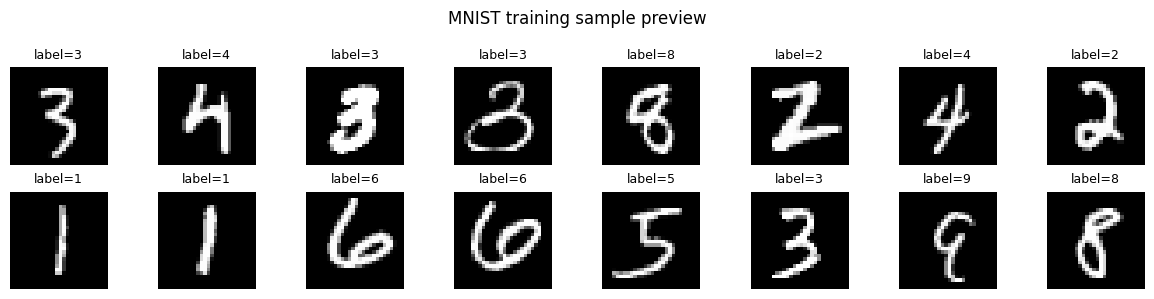

Sample images logged.


wandb: WARNING Artifact "mnist-selected-images" already exists with the same content. No new version will be created.


In [4]:
# ── Visualise a few training images ──
image_fig = make_mnist_samples_figure(
    X_train_pixels[:16],
    y_train_np[:16],
    title="MNIST training sample preview",
)
plt.show()

# Log to W&B and save as a CSV artifact
log_figure(run, "data/sample_images", image_fig)
log_features_as_csv_artifact(
    run,
    artifact_name="mnist-selected-images",
    output_dir=output_dir / "images",
    arrays={
        "X_train_pixels": (X_train_pixels, y_train_np),
        "X_test_pixels":  (X_test_pixels,  y_test_np),
    },
)
print("Sample images logged.")


---

## 2 · Classical Pre-processing — PCA + Min-Max Scaling

### Why PCA?
Our quantum circuit has a fixed number of input modes (`N_QFEATURES = 12`).  
We cannot directly feed 784-dimensional pixel vectors into it, so we first compress the data with **Principal Component Analysis (PCA)**.

PCA finds the directions of maximum variance in the training data.  
Projecting onto the top-$k$ components preserves as much information as possible while reducing the dimension to $k$.

### Why min-max scaling?
Circuit angles (beam-splitter transmittances) must lie in **[0, 1]**.  
We therefore rescale each PCA component using the global min and max computed on the *training set only*:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min} + \varepsilon}$$

> **Important:** The test set is transformed with the *training-set* statistics to avoid data leakage.

> **Exercise:** Try `N_QFEATURES = 6` or `24`.  How does the explained variance change, and how does it affect downstream accuracy?


In [5]:
def minmax_normalize(data: np.ndarray, global_min: float, global_max: float) -> np.ndarray:
    """Scale `data` to [0, 1] using pre-computed global min and max."""
    epsilon = 1e-8
    return (data - global_min) / (global_max - global_min + epsilon)


# ── Fit PCA on train, transform both splits ──
pca = PCA(n_components=N_QFEATURES, random_state=123)
X_train_pca = pca.fit_transform(X_train_pixels)   # (500, 12)
X_test_pca  = pca.transform(X_test_pixels)         # (100, 12)

# ── Compute scaling statistics on train only ──
pca_global_min = X_train_pca.min()
pca_global_max = X_train_pca.max()

X_train_q = minmax_normalize(X_train_pca, pca_global_min, pca_global_max)
X_test_q  = minmax_normalize(X_test_pca,  pca_global_min, pca_global_max)

print(f"PCA output dim     : {X_train_q.shape[1]}")
print(f"Explained variance : {pca.explained_variance_ratio_.sum():.2%}  ({N_QFEATURES} components)")
print(f"PCA global min/max : {pca_global_min:.4f} / {pca_global_max:.4f}")
print(f"X_train_q range    : [{X_train_q.min():.4f}, {X_train_q.max():.4f}]")

run.log({
    "pca/global_min":              float(pca_global_min),
    "pca/global_max":              float(pca_global_max),
    "pca/explained_variance_sum":  float(pca.explained_variance_ratio_.sum()),
})


PCA output dim     : 12
Explained variance : 53.59%  (12 components)
PCA global min/max : -5.3825 / 7.8062
X_train_q range    : [0.0000, 1.0000]


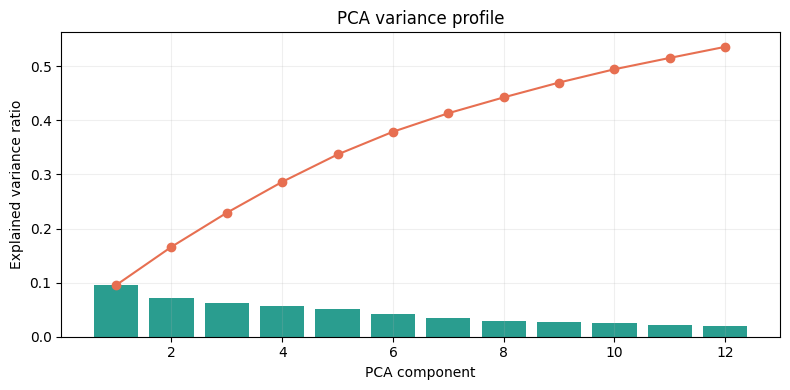

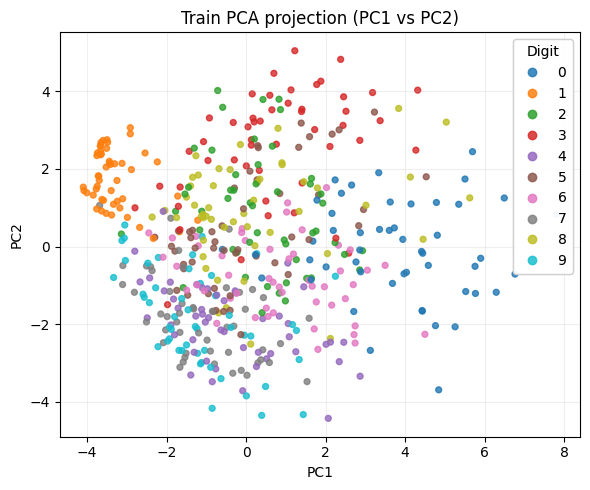

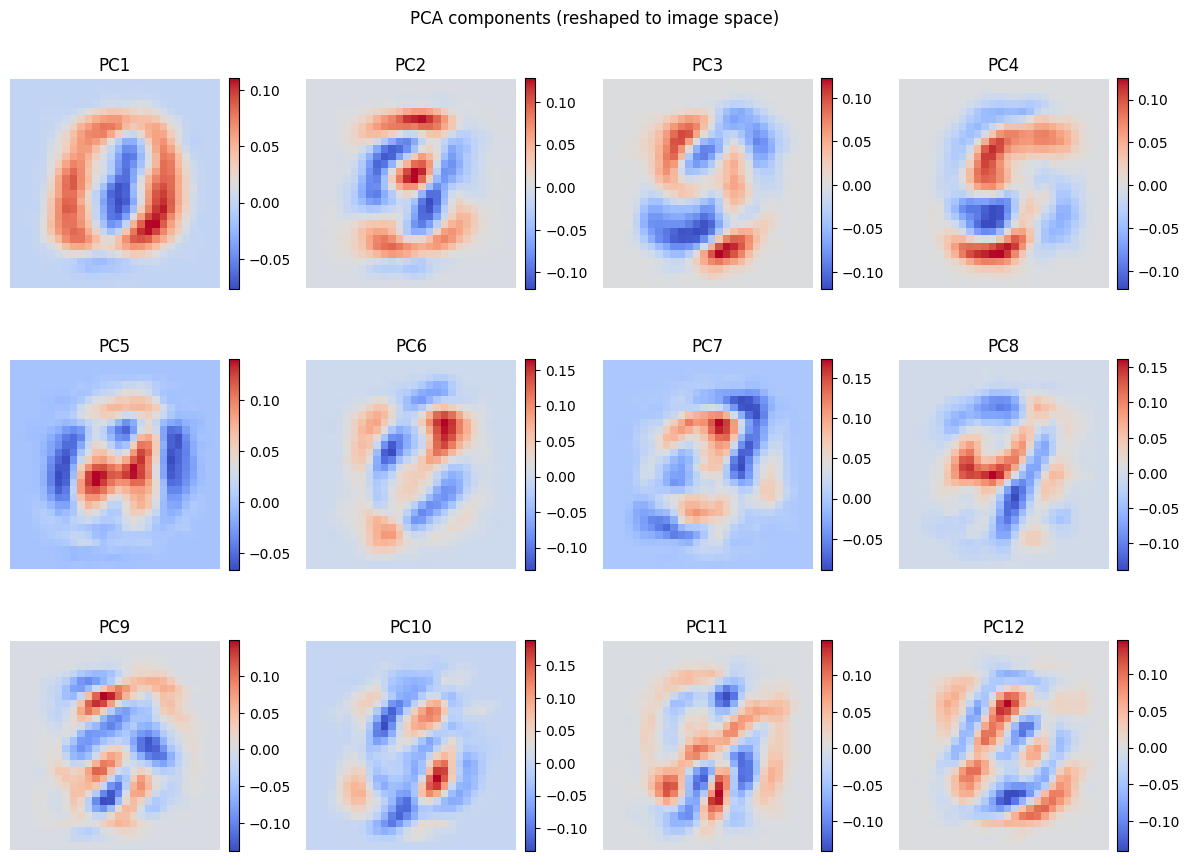

In [6]:
# ── Visualise PCA results ──

# 1. Scree plot — share of variance per component
fig_var = make_pca_variance_figure(pca)
plt.show()
log_figure(run, "pca/explained_variance", fig_var)

# 2. Scatter plot of the first two principal components (colour = class)
fig_proj = make_pca_projection_figure(X_train_pca, y_train_np, "Train PCA projection (PC1 vs PC2)")
plt.show()
log_figure(run, "pca/train_projection_pc1_pc2", fig_proj)

# 3. Spatial layout of each principal component (reshape to 28×28)
fig_comp = make_pca_components_figure(pca, n_components=N_QFEATURES)
plt.show()
log_figure(run, "pca/components", fig_comp)


---

## 3 · Classical Baseline — Linear SVC on Raw Pixels

Before introducing any quantum component it is essential to establish a **classical baseline** — a model with no quantum features.

Here we train a **Linear Support Vector Classifier (L-SVC)** directly on the flattened pixel vectors.  
This gives us the *minimum bar* the quantum model must beat to be worth the added complexity.

| What | Value |
|---|---|
| Model | `LinearSVC(dual=False)` |
| Input | 784-dim pixel vector |
| Output | digit 0–9 |

> **Note:** L-SVC is a strong classifier for small datasets.  Do not be surprised if the quantum model only matches — or slightly exceeds — it on 500 training samples.


L-SVC baseline accuracy : 0.8300  (83/100 correct)


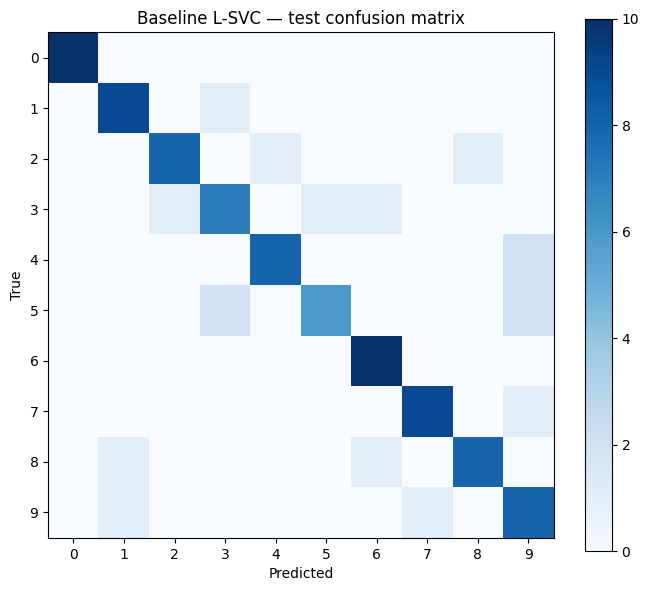

In [7]:
# ── Train L-SVC on raw pixels ──
baseline = LinearSVC(dual=False, random_state=123, max_iter=20_000)
baseline.fit(X_train_pixels, y_train_np)
baseline_preds = baseline.predict(X_test_pixels)
baseline_acc   = accuracy_score(y_test_np, baseline_preds)

print(f"L-SVC baseline accuracy : {baseline_acc:.4f}  ({int(baseline_acc * len(y_test_np))}/{len(y_test_np)} correct)")

# ── Log to W&B ──
run.log({"baseline/accuracy": float(baseline_acc)})
fig_cm_baseline = make_confusion_matrix_figure(
    y_test_np, baseline_preds, "Baseline L-SVC — test confusion matrix"
)
plt.show()
log_figure(run, "baseline/test_confusion_matrix", fig_cm_baseline)


---

## 4 · Building the Quantum Reservoir

### Architecture overview

The circuit is built with **MerLin's `CircuitBuilder`** and mirrors the architecture described in Rambach *et al.* (Fig. 1):

```
Input state  →  [Pre-circuit]  →  [Phase encoding]  →  [Reservoir]  →  Measurement
                 (entangling)      (angle encoding)     (entangling)
```

| Paper name | MerLin call | Role |
|---|---|---|
| **Pre-circuit** | `add_entangling_layer()` | First fixed random interferometer — creates initial many-photon entanglement. |
| **Phase encoding** | `add_angle_encoding(modes=…)` | Data-dependent phase shifters angles set to the PCA input values. This is how classical data enters the circuit. |
| **Reservoir** | `add_entangling_layer()` | Second fixed random interferometer — further mixes the photon amplitudes to produce a rich quantum fingerprint. |

### Input state
Following the paper's experimental setup ($N{=}3$, $M{=}12$), we inject **3 photons** into modes 0, 2, 4 of a 12-mode circuit:  
$|1,0,1,0,1,0,0,0,0,0,0,0\rangle$

The photons interfere through the circuit, and measuring the output photon distribution gives us a high-dimensional feature vector whose size grows combinatorially as $\binom{N+M-1}{N}$.

### Why is the reservoir *fixed*?
Unlike variational quantum circuits (VQC), the entangling layers are **randomly initialised and frozen**.  
Only the phase-encoding layer receives the data.  
This is the key idea of **reservoir computing** (Rambach *et al.*, Sec. 1): the random fixed dynamics project the input into an exponentially large Hilbert space; we only train the cheap linear readout.

> **Note:** The two random interferometers can in principle differ, but as Rambach *et al.* note, "for simplicity we have chosen them to be the same in all our experiments." MerLin's `add_entangling_layer()` draws independent random parameters, so the two layers will generally differ here — which is equally valid.

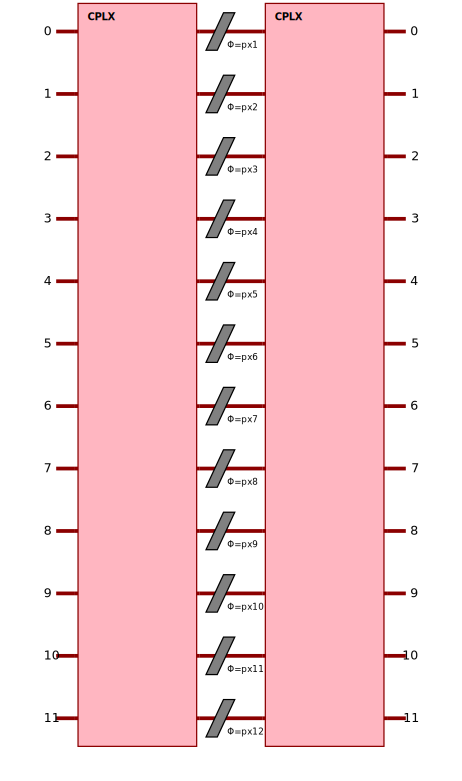

In [8]:
# ── Build the quantum reservoir circuit ──
#
# CircuitBuilder(n_modes=12) creates a 12-mode photonic circuit.
# The three layers are:
#   1. add_entangling_layer()    — random beam-splitters (fixed weights)
#   2. add_angle_encoding()      — data-dependent beam-splitter angles
#   3. add_entangling_layer()    — another random entangling layer (fixed)

builder = ML.CircuitBuilder(n_modes=N_QFEATURES)
builder.add_entangling_layer()
builder.add_angle_encoding(modes=range(N_QFEATURES))
builder.add_entangling_layer()

# QuantumLayer wraps the circuit as a PyTorch-compatible module.
# input_state: Fock state with photons in modes 0, 2, 4
reservoir = ML.QuantumLayer(
    builder=builder,
    input_state=[1, 0, 1, 0, 1, 0] + ([0] * (N_QFEATURES - 6)),
).eval()   # eval() → no gradient tracking, reservoir weights frozen

# Display the circuit schematic (Perceval renders it inline in the notebook)
pcvl.pdisplay(reservoir.circuit)


In [9]:
# ── Export circuit description and log to W&B ──
export_and_log_circuit(reservoir, run, output_dir / "circuit")
print("Circuit exported and logged.")


wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


Circuit exported and logged.


---

## 5 · Extracting Quantum Features — Ideal Simulator

### How it works

For each input sample $\mathbf{x} \in [0,1]^{12}$:
1. The values of $\mathbf{x}$ are loaded into the phase-encoding layer of the circuit.
2. The circuit is simulated **exactly** (no shot noise) on a classical computer using Perceval's built-in permanent-based simulator.
3. The output probabilities of each Fock-basis measurement outcome form the **quantum fingerprint** $\mathbf{z} \in \mathbb{R}^d$.

In Rambach *et al.*'s terminology, this is the "noiseless" / "ideal" simulation (the teal curve in their Fig. 5).  The feature dimension $d$ is the number of distinct multi-photon coincidence patterns, which grows combinatorially as $\binom{N+M-1}{N}$ — for $N{=}3, M{=}12$ this gives $d = 91$ additional features.

### Post-processing
Before feeding the quantum features to the readout, we:
1. **Standardise** them to zero mean and unit variance using training-set statistics:  
   $z_{\text{norm}} = \dfrac{z - \mu_{\text{train}}}{\sigma_{\text{train}} + \varepsilon}$
2. **Concatenate** the normalised quantum features with the raw pixel vector:  
   $\mathbf{h} = [\mathbf{x}_{\text{pixels}} \;\|\; \mathbf{z}_{\text{norm}}]$

The concatenation preserves all original information and lets the readout decide how much to weight the quantum enhancement.  This corresponds to input **(ii) QORC** in Rambach *et al.* (Table 1).

In [10]:
def as_numpy(x) -> np.ndarray:
    """Convert a tensor or array-like to a NumPy array."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def standard_normalize(data: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """Zero-centre and unit-scale `data` with pre-computed train statistics."""
    epsilon = 1e-8
    return (data - mean) / (std + epsilon)


def extract_ideal_features(x_np: np.ndarray) -> np.ndarray:
    """Run the reservoir on CPU (ideal noiseless simulation)."""
    with torch.no_grad():
        z = reservoir(torch.tensor(x_np, dtype=torch.float32))
    return as_numpy(z)


print("Running ideal (noiseless) quantum simulation …")
Z_train_ideal = extract_ideal_features(X_train_q)   # (500, d_quantum)
Z_test_ideal  = extract_ideal_features(X_test_q)    # (100, d_quantum)

print(f"Quantum feature dim : {Z_train_ideal.shape[1]}")
print(f"Z_train_ideal shape : {Z_train_ideal.shape}")
print(f"Z_test_ideal  shape : {Z_test_ideal.shape}")

# ── Log features as CSV artifacts ──
log_features_as_csv_artifact(
    run,
    artifact_name="qorc-ideal-features",
    output_dir=output_dir / "features",
    arrays={
        "Z_train_ideal": (Z_train_ideal, y_train_np),
        "Z_test_ideal":  (Z_test_ideal,  y_test_np),
    },
)

# ── Standardise and concatenate with raw pixels ──
qorc_mean_ideal = Z_train_ideal.mean(axis=0)
qorc_std_ideal  = Z_train_ideal.std(axis=0)

Z_train_ideal_norm = standard_normalize(Z_train_ideal, qorc_mean_ideal, qorc_std_ideal)
Z_test_ideal_norm  = standard_normalize(Z_test_ideal,  qorc_mean_ideal, qorc_std_ideal)

# Final feature matrix: [raw pixels (784) | quantum features (d)]
X_train_ideal = np.concatenate([X_train_pixels, Z_train_ideal_norm], axis=1)
X_test_ideal  = np.concatenate([X_test_pixels,  Z_test_ideal_norm],  axis=1)

print(f"\nFinal feature dim (pixels + quantum) : {X_train_ideal.shape[1]}")


Running ideal (noiseless) quantum simulation …
Quantum feature dim : 220
Z_train_ideal shape : (500, 220)
Z_test_ideal  shape : (100, 220)

Final feature dim (pixels + quantum) : 1004


---

## 6 · Training the Linear Readout

### Why a linear readout?

The whole point of the reservoir approach is that **only the readout is trained**.  
By keeping it linear (a single `nn.Linear` layer), we demonstrate that the quantum reservoir is doing real work: any non-linear separation in the feature space must come from the circuit, not the classifier.

### Training setup

| Component | Choice |
|---|---|
| Architecture | `nn.Linear(features_in, 10)` |
| Loss | Cross-entropy |
| Optimiser | Adam |
| Epochs | `READOUT_EPOCHS` = 300 |
| Learning rate | `READOUT_LR` = 1e-2 |

A validation split (`VAL_FRACTION = 0.2`) is carved out of the training set to monitor over-fitting.  
Training/validation/test curves and confusion matrices are logged to W&B every `CONFUSION_LOG_EVERY` epochs.


In [11]:
def train_linear_readout(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val:   np.ndarray,
    y_val:   np.ndarray,
    X_test:  np.ndarray,
    y_test:  np.ndarray,
    run: "wandb.sdk.wandb_run.Run",
    run_prefix: str,
    n_epochs: int = READOUT_EPOCHS,
    lr: float = READOUT_LR,
    seed: int = 123,
    confusion_every: int = CONFUSION_LOG_EVERY,
) -> tuple[np.ndarray, torch.nn.Linear]:
    """
    Train a single linear layer (nn.Linear) as the readout classifier.

    Parameters
    ----------
    X_train / X_val / X_test : feature matrices
    y_train / y_val / y_test : integer class labels
    run          : active W&B run for logging
    run_prefix   : string prefix for W&B metric names (e.g. 'ideal_readout')
    n_epochs     : number of gradient-descent steps
    lr           : Adam learning rate
    seed         : for weight initialisation reproducibility
    confusion_every : log a confusion-matrix figure every N epochs

    Returns
    -------
    final_preds : predicted class labels on the test set
    model       : trained nn.Linear module
    """
    torch.manual_seed(seed)

    n_features = X_train.shape[1]
    model      = torch.nn.Linear(n_features, 10)
    optimiser  = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn    = torch.nn.CrossEntropyLoss()

    # Convert to tensors once
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

    run.summary[f"{run_prefix}_model"] = str(model)
    try:
        run.watch(model, log="all", log_freq=max(1, n_epochs // 10))
    except Exception:
        pass  # harmless if called more than once

    for epoch in range(1, n_epochs + 1):
        # ── forward + backward pass ──
        model.train()
        optimiser.zero_grad()
        train_logits = model(X_train_t)
        train_loss   = loss_fn(train_logits, y_train_t)
        train_loss.backward()
        optimiser.step()

        # ── evaluation (no gradients needed) ──
        model.eval()
        with torch.no_grad():
            val_logits  = model(X_val_t)
            val_loss    = loss_fn(val_logits, y_val_t)
            test_logits = model(X_test_t)

            train_preds = train_logits.argmax(dim=1).cpu().numpy()
            val_preds   = val_logits.argmax(dim=1).cpu().numpy()
            test_preds  = test_logits.argmax(dim=1).cpu().numpy()

        train_acc = accuracy_score(y_train, train_preds)
        val_acc   = accuracy_score(y_val,   val_preds)
        test_acc  = accuracy_score(y_test,  test_preds)

        run.log(
            {
                f"{run_prefix}/train_loss": float(train_loss.item()),
                f"{run_prefix}/val_loss":   float(val_loss.item()),
                f"{run_prefix}/train_acc":  float(train_acc),
                f"{run_prefix}/val_acc":    float(val_acc),
                f"{run_prefix}/test_acc":   float(test_acc),
                f"{run_prefix}/epoch":      epoch,
            },
            step=epoch,
        )

        # ── periodic confusion-matrix logging ──
        if epoch % confusion_every == 0 or epoch == 1 or epoch == n_epochs:
            cm_fig = make_confusion_matrix_figure(
                y_true=y_test,
                y_pred=test_preds,
                title=f"{run_prefix} — test confusion matrix (epoch {epoch})",
            )
            run.log({f"{run_prefix}/test_confusion_matrix": wandb.Image(cm_fig)}, step=epoch)
            plt.close(cm_fig)

    # ── final predictions ──
    model.eval()
    with torch.no_grad():
        final_preds = model(X_test_t).argmax(dim=1).cpu().numpy()

    run.summary[f"{run_prefix}_final_test_acc"] = float(accuracy_score(y_test, final_preds))
    return final_preds, model


print("train_linear_readout() defined.")


train_linear_readout() defined.


wandb: WARNING Artifact "qorc-ideal-features" already exists with the same content. No new version will be created.


In [12]:
# ── Split training set into train / validation ──
X_train_ideal_fit, X_val_ideal, y_train_ideal_fit, y_val_ideal = train_test_split(
    X_train_ideal,
    y_train_np,
    test_size=VAL_FRACTION,
    random_state=123,
    stratify=y_train_np,
)

print(f"Train split : {X_train_ideal_fit.shape[0]} samples")
print(f"Val split   : {X_val_ideal.shape[0]} samples")
print(f"Feature dim : {X_train_ideal_fit.shape[1]}")
print("\nTraining linear readout on ideal quantum features …")

ideal_preds, ideal_model = train_linear_readout(
    X_train=X_train_ideal_fit,
    y_train=y_train_ideal_fit,
    X_val=X_val_ideal,
    y_val=y_val_ideal,
    X_test=X_test_ideal,
    y_test=y_test_np,
    run=run,
    run_prefix="ideal_readout",
    seed=123,
)

ideal_acc = accuracy_score(y_test_np, ideal_preds)
run.log({"ideal/accuracy": float(ideal_acc)})
run.summary["ideal_model_parameters"] = int(sum(p.numel() for p in ideal_model.parameters()))

print(f"\nMerLin ideal accuracy : {ideal_acc:.4f}  ({int(ideal_acc * len(y_test_np))}/{len(y_test_np)} correct)")


Train split : 400 samples
Val split   : 100 samples
Feature dim : 1004

Training linear readout on ideal quantum features …

MerLin ideal accuracy : 0.8300  (83/100 correct)


wandb: WARNING Tried to log to step 1 that is less than the current step 8. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 2 that is less than the current step 8. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 3 that is less than the current step 8. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 4 that is less than the current step 8. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 5 that is less than the current step 8. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/defin

---

## 7 · (Optional) Remote Quantum Processor — MerLinProcessor

### What changes?
Instead of the local noiseless simulator, we now forward the data through a **real (or noise-model) remote photonic processor** hosted by Quandela Cloud.

`MerlinProcessor` handles:
- **Batching:** splits the dataset into micro-batches to respect API rate limits.
- **Shot noise:** real hardware produces probabilistic measurement outcomes; the feature vectors are now averages over `max_shots_per_call` shots.
- **Timeouts & retries:** configurable via `timeout` and `chunk_concurrency`.

The processor features are then standardised and concatenated with raw pixels, exactly as in the ideal run.

### Obtaining a cloud token
1. Register at [cloud.quandela.com](https://cloud.quandela.com).
2. Create a `.env` file in this folder containing:
   ```
   CLOUD_TOKEN=your_token_here
   ```
3. Re-run the cell below — it will pick up the token automatically.

> **Skip:** if `CLOUD_TOKEN` is not set, this section is silently skipped and the final comparison table shows "N/A" for the processor row.


In [14]:
CLOUD_TOKEN    = load_cloud_token()
processor_acc  = None   # will be filled in if token is available

# Collect all embeddings for the final .npz artifact
embeddings_payload: dict[str, np.ndarray] = {
    "X_train_pixels":       X_train_pixels,
    "X_test_pixels":        X_test_pixels,
    "X_train_pca":          X_train_pca,
    "X_test_pca":           X_test_pca,
    "X_train_q":            X_train_q,
    "X_test_q":             X_test_q,
    "Z_train_ideal":        Z_train_ideal,
    "Z_test_ideal":         Z_test_ideal,
    "Z_train_ideal_norm":   Z_train_ideal_norm,
    "Z_test_ideal_norm":    Z_test_ideal_norm,
    "y_train":              y_train_np,
    "y_test":               y_test_np,
}

if not CLOUD_TOKEN:
    print("MerLinProcessor run skipped – set CLOUD_TOKEN in your .env file.")
    run.summary["processor_status"] = "skipped_no_cloud_token"

else:
    print("Connecting to remote quantum processor (sim:belenos) …")
    pcvl.RemoteConfig.set_token(CLOUD_TOKEN)
    remote_processor = pcvl.RemoteProcessor("sim:belenos")
    print("Connection established.")

    # ── MerlinProcessor wraps the remote backend ──
    proc = ML.MerlinProcessor(
        remote_processor,
        microbatch_size=32,   # samples per API call
        timeout=3600.0,       # max seconds to wait for a batch
        max_shots_per_call=100,
        chunk_concurrency=1,
    )

    x_train_q_t = torch.tensor(X_train_q, dtype=torch.float32)
    x_test_q_t  = torch.tensor(X_test_q,  dtype=torch.float32)

    print(f"Sending training data ({X_train_q.shape[0]} samples) to the quantum processor …")
    Z_train_proc = as_numpy(proc.forward(reservoir, x_train_q_t))
    print("Training data retrieved.")

    print(f"Sending test data ({X_test_q.shape[0]} samples) to the quantum processor …")
    Z_test_proc  = as_numpy(proc.forward(reservoir, x_test_q_t))
    print("Test data retrieved.")

    log_features_as_csv_artifact(
        run,
        artifact_name="qorc-processor-features",
        output_dir=output_dir / "features",
        arrays={
            "Z_train_proc": (Z_train_proc, y_train_np),
            "Z_test_proc":  (Z_test_proc,  y_test_np),
        },
    )

    # ── Standardise and concatenate with pixels ──
    print("Normalising processor quantum features …")
    qorc_mean_proc = Z_train_proc.mean(axis=0)
    qorc_std_proc  = Z_train_proc.std(axis=0)

    Z_train_proc_norm = standard_normalize(Z_train_proc, qorc_mean_proc, qorc_std_proc)
    Z_test_proc_norm  = standard_normalize(Z_test_proc,  qorc_mean_proc, qorc_std_proc)

    X_train_proc = np.concatenate([X_train_pixels, Z_train_proc_norm], axis=1)
    X_test_proc  = np.concatenate([X_test_pixels,  Z_test_proc_norm],  axis=1)

    X_train_proc_fit, X_val_proc, y_train_proc_fit, y_val_proc = train_test_split(
        X_train_proc, y_train_np,
        test_size=VAL_FRACTION, random_state=123, stratify=y_train_np,
    )

    print("Training linear readout on processor features …")
    proc_preds, proc_model = train_linear_readout(
        X_train=X_train_proc_fit,
        y_train=y_train_proc_fit,
        X_val=X_val_proc,
        y_val=y_val_proc,
        X_test=X_test_proc,
        y_test=y_test_np,
        run=run,
        run_prefix="processor_readout",
        seed=123,
    )
    processor_acc = accuracy_score(y_test_np, proc_preds)
    print(f"MerLinProcessor accuracy : {processor_acc:.4f}")

    run.log({"processor/accuracy": float(processor_acc)})
    run.summary["processor_model_parameters"] = int(sum(p.numel() for p in proc_model.parameters()))

    embeddings_payload.update({
        "Z_train_processor":      Z_train_proc,
        "Z_test_processor":       Z_test_proc,
        "Z_train_processor_norm": Z_train_proc_norm,
        "Z_test_processor_norm":  Z_test_proc_norm,
    })


Connecting to remote quantum processor (sim:belenos) …
Connection established.
Sending training data (500 samples) to the quantum processor …
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consistency.
[warning] Lowered 'max_samples' from user defined value (10000) to 'max_shots' value (100) for consist

Chunk attempt 1/3 failed: HTTPSConnectionPool(host='api.cloud.quandela.com', port=443): Max retries exceeded with url: /api/job/status/73c7511e-c144-4a05-b074-74ee6554abde (Caused by NameResolutionError("HTTPSConnection(host='api.cloud.quandela.com', port=443): Failed to resolve 'api.cloud.quandela.com' ([Errno 8] nodename nor servname provided, or not known)"))


ConnectionError: HTTPSConnectionPool(host='api.cloud.quandela.com', port=443): Max retries exceeded with url: /api/platforms/sim%3Abelenos/processor (Caused by NameResolutionError("HTTPSConnection(host='api.cloud.quandela.com', port=443): Failed to resolve 'api.cloud.quandela.com' ([Errno 8] nodename nor servname provided, or not known)"))

---

## 8 · Results & Comparison

We collect all three accuracy scores into a summary table and log it to W&B.

After this cell:
- All intermediate embeddings (pixel features, PCA projections, quantum features) are saved locally as an `.npz` file and uploaded to W&B as an artifact.
- The W&B run is cleanly finished with `wandb.finish()`.

### Interpreting the results

| Model | Reservoir | Expected behaviour | Paper reference |
|---|---|---|---|
| L-SVC baseline | none | Strong classical reference | Rambach *et al.*, Table 1 row (i) |
| MerLin ideal | noiseless sim | Equal or better than baseline — the quantum fingerprint adds non-linear features that a linear readout cannot extract from pixels alone | Table 1 row (ii): +4% test accuracy on full MNIST |
| MerLinProcessor | photonic hardware | Slightly below ideal due to shot noise; may improve with more shots | Fig. 5 (orange): QPU matches ideal within error bars |

> **Key takeaway:** On small datasets the quantum advantage may be modest.  Rambach *et al.* show the improvement scales with data scarcity — QORC achieves peak L-SVC accuracy with up to **20× fewer training images** (Fig. 5).  
> The goal of this notebook is to understand the *end-to-end pipeline* and reproduce the scheme hands-on, not to claim supremacy on 500 samples.

In [ ]:
# ── Save all embeddings as a compressed .npz artifact ──
save_embeddings(output_dir=output_dir, run=run, embedding_dict=embeddings_payload)

# ── Build results table and log to W&B ──
rows = [
    ["L-SVC baseline",             float(baseline_acc)],
    ["MerLin ideal (local sim)",   float(ideal_acc)],
    ["MerLinProcessor (remote)",   None if processor_acc is None else float(processor_acc)],
]
results_table = wandb.Table(columns=["run", "accuracy"], data=rows)
run.log({"results/accuracy_table": results_table})

# ── Print summary ──
print("=" * 55)
print("  Accuracy comparison")
print("=" * 55)
print(f"  L-SVC baseline              : {baseline_acc:.4f}")
print(f"  MerLin ideal (local sim)    : {ideal_acc:.4f}")
if processor_acc is None:
    print("  MerLinProcessor             : skipped (no CLOUD_TOKEN)")
else:
    print(f"  MerLinProcessor (hardware)  : {processor_acc:.4f}")
print("=" * 55)

# ── Finish W&B run ──
wandb.finish()
print("\nW&B run finished. All artifacts have been saved.")


---

## 9 · Going Further

### Exercises

1. **More data:** Increase `PER_CLASS_TRAIN` to 100 or 200.  Does the quantum advantage grow?  Rambach *et al.* (Fig. 5) show QORC surpasses peak L-SVC accuracy with ~20× fewer training images.
2. **Fewer PCA components:** Try `N_QFEATURES = 6`.  How much variance is lost, and how does accuracy change?
3. **Different input states:** Change the Fock input state to `[1,1,0,0,…]` (two adjacent photons).  How does interference change the features?  Rambach *et al.* (Supplemental Sec. S4) explore different $N$ and input states.
4. **More entangling layers:** Add a third `builder.add_entangling_layer()`.  Does the reservoir become richer?
5. **Remove pixel concatenation:** Train the readout on quantum features *only* (remove `X_train_pixels` from the concatenation).  Rambach *et al.* (Table 1, row iii) find that reservoir-only features still beat the baseline.
6. **SVC readout:** Replace `nn.Linear` with `LinearSVC`.  Do you get a different accuracy / training time trade-off?
7. **Photon indistinguishability:** Rambach *et al.* (Fig. 3) show that QORC remains advantageous even for fully distinguishable photons ($\mathcal{I}=0$) due to first-order quantum coherence.  Explore this by adding noise to the simulator if MerLin supports it.

### Further reading

- **Rambach *et al.*** (2025) — *Photonic Quantum-Accelerated Machine Learning*, [arXiv:2512.08318](https://arxiv.org/abs/2512.08318) — the paper this notebook reproduces.
- **Sakurai *et al.*** (2025) — *Quantum Optical Reservoir Computing*, [arXiv:2502.03805](https://arxiv.org/abs/2502.03805) — the original QORC proposal.
- Mujal *et al.* (2021) — *Opportunities in Quantum Reservoir Computing and Extreme Learning Machines*, Adv. Quantum Technol.
- Perceval documentation: [perceval.quandela.net](https://perceval.quandela.net)
- MerLin documentation: [merlin.quandela.net](https://merlin.quandela.net)
- Weights & Biases documentation: [docs.wandb.ai](https://docs.wandb.ai)